In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from generate_colormap import *


from functools import partial
import starsim

from scipy.ndimage import gaussian_filter

In [2]:
def generate_grid_coordinates_nb(N):

    Nt=2*N-1 #N is number of concentric rings. Nt is counting them two times minus the center one.
    width=180.0/(2*N-1) #width of one grid element.

    centres=np.append(0,np.linspace(width,90-width/2,N-1)) #colatitudes of the concentric grids. The pole of the grid faces the observer.
    anglesout=np.linspace(0,360-width,2*Nt) #longitudes of the grid edges of the most external grid. This grids fix the area of the grids in other rings.
    
    radi=np.sin(np.pi*centres/180) #projected polar radius of the ring.
    amu=np.cos(np.pi*centres/180) #amus

    ts=[0.0] #central grid radius
    alphas=[0.0] #central grid angle

    area=[2.0*np.pi*(1.0-np.cos(width*np.pi/360.0))] #area of spherical cap (only for the central element)
    parea=[np.pi*np.sin(width*np.pi/360.0)**2]

    Ngrid_in_ring=[1]
    
    for i in range(1,len(amu)): #for each ring except firs
        Nang=int(round(len(anglesout)*(radi[i]))) #Number of longitudes to have grids of same width
        w=360/Nang #width i angles
        Ngrid_in_ring.append(Nang)

        angles=np.linspace(0,360-w,Nang)
        area.append(radi[i]*width*w*np.pi*np.pi/(180*180)) #area of each grid
        parea.append(amu[i]*area[-1]) #PROJ. AREA OF THE GRID

        for j in range(Nang):
            ts.append(centres[i]) #latitude
            alphas.append(angles[j]) #longitude


    alphas=np.array(alphas) #longitude of grid (pole faces observer)
    ts=np.array(ts) #colatitude of grid
    Ngrids=len(ts)  #number of grids

    rs = np.sin(np.pi*ts/180) #projected polar radius of grid

    xs = np.cos(np.pi*ts/180) #grid elements in cartesian coordinates. Note that pole faces the observer.
    ys = rs*np.sin(np.pi*alphas/180)
    zs = -rs*np.cos(np.pi*alphas/180)

    return Ngrids,Ngrid_in_ring, centres, amu, rs, alphas, xs, ys, zs, area, parea

In [3]:
N = 60
Ngrids,Ngrid_in_ring, centres, amu, rs, alphas, xs, ys, zs, area, parea = generate_grid_coordinates_nb(N)

In [4]:
np.sum(Ngrid_in_ring[:55])

np.int64(7830)

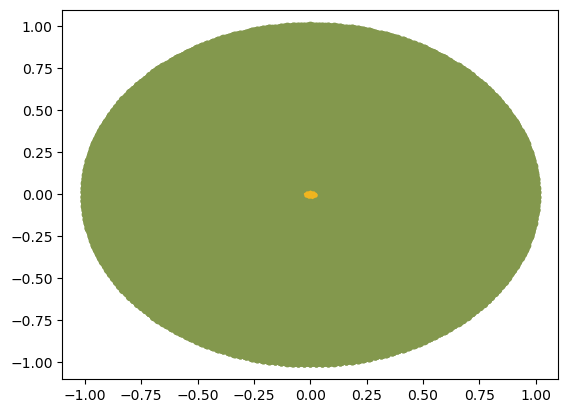

In [5]:
colors = ['#336b8b', '#f0b51f', '#83984d', '#fa8072', '#cab8d9']

plt.scatter(ys[0], zs[0], color=colors[0])
plt.scatter(ys[1:7], zs[1:7], color=colors[1])
plt.scatter(ys[7:], zs[7:], color=colors[2])
plt.show()

theta_s = np.arctan2(ys,zs)


In [6]:
n = 5
x = np.linspace(-1,1,n)

xg, yg = np.meshgrid(x, x)
rg = np.sqrt(xg**2 + yg**2)


xg = np.where(rg>1, np.nan, xg)
yg = np.where(rg>1, np.nan, yg)
rg = np.where(rg>1, np.nan, rg)
theta_g = np.arctan2(xg, yg) - np.pi / 2
theta_g = np.where(theta_g<0, theta_g + 2*np.pi, theta_g)


r = np.unique(np.round(rs, decimals=6))

#TODO change the lim to have the same area as in starsim
lim_r = np.zeros(N)
for i in range(len(lim_r)-1):
    lim_r[i] = (r[i+1] + r[i]) / 2

lim_r[-1] = 1
# print(lim_r)

xg = xg.reshape(n**2)
yg = yg.reshape(n**2)
rg = rg.reshape(n**2)
theta_g = theta_g.reshape(n**2)

ngrid_g = np.nan * np.ones(n**2)

typ_ring = np.zeros(n**2)
typ_cell = np.zeros(n**2)



for i in range(len(xg)):
    if rg[i]>0:
        typ_ring[i] = np.argwhere(lim_r>=rg[i]).min()
    else:
        typ_ring[i] = np.nan

for i in range(len(xg)):
    if typ_ring[i] == 0:
        typ_cell[i] = 0
    elif typ_ring[i]>0:
        phi_step = 2*np.pi / Ngrid_in_ring[int(typ_ring[i])]
        typ_cell[i] = np.round((theta_g[i] + np.pi / 2) % (2 * np.pi) / phi_step) + np.sum(Ngrid_in_ring[:int(typ_ring[i])])
        print(int(typ_ring[i]),typ_cell[i], np.round((theta_g[i] + np.pi / 2) % (2 * np.pi) / phi_step) )
    else:
        typ_cell[i] = np.nan


59 8897.0 119.0
30 2706.0 106.0
20 1229.0 60.0
30 2663.0 63.0
59 8956.0 178.0
20 1259.0 90.0
20 1199.0 30.0
59 8838.0 60.0
30 2748.0 148.0
20 1169.0 0.0
30 2621.0 21.0
59 8778.0 0.0


In [7]:
# colors = ['royalblue', 'maroon', 'indigo', 'plum', 'darkseagreen', 'darkviolet', 'peru', 'navy', 'pink', 'yellowgreen', 'peachpuff', 'teal', 'purple', 'gold', 'aqua', 'olive', 'palegreen']

# for i in range(len(xs)):
#     plt.scatter(ys[i], zs[i], color=colors[i])

# for i in range(len(xg)):
#     if typ_cell[i]>=0:
#         plt.plot(xg[i], yg[i], '.', color=colors[int(typ_cell[i])])


[[nan nan 13. nan nan]
 [nan 15.  4. 12. nan]
 [17.  5.  0.  3. 10.]
 [nan 18.  1.  9. nan]
 [nan nan  7. nan nan]]


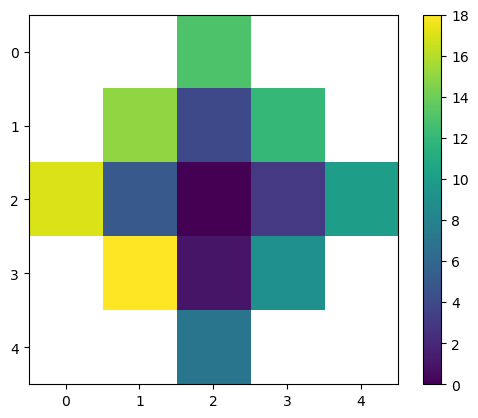

In [8]:
n_typ =  [[0, 0, 2, 0, 0], [0, 2, 1, 2, 0], [2, 1, 0, 1, 2], [0, 2, 1, 2, 0], [0, 0, 2, 0, 0]]
n_ring = [[0, 0, 7, 0, 0], [0, 7, 1, 7, 0], [7, 1, 0, 1, 7], [0, 7, 1, 7, 0], [0, 0, 7, 0, 0]]

x = np.round((theta_g.reshape(n,n) + np.pi/2) % (2 * np.pi) / (2*np.pi / np.array(Ngrid_in_ring)[n_typ])) + n_ring
plt.imshow(x)
plt.colorbar()

print(x)

In [9]:
x = x.reshape(n**2)
n_typ = np.array(n_typ).reshape(n**2)
for i in range(n**2): 
    x[i] = x[i] % (Ngrid_in_ring[n_typ[i]])
x = x.reshape(n,n)
print(x)

[[nan nan  0. nan nan]
 [nan  2.  4. 12. nan]
 [ 4.  5.  0.  3. 10.]
 [nan  5.  1.  9. nan]
 [nan nan  7. nan nan]]


[0.2938925 0.769421  1.       ]


/tmp/ipykernel_68215/3491609301.py:48: RuntimeWarning: divide by zero encountered in divide
  typ_cell = np.round((theta_g.reshape(n,n) + np.pi/2) % (2 * np.pi) / (2*np.pi /(n_ring))) % n_ring + offset_ring


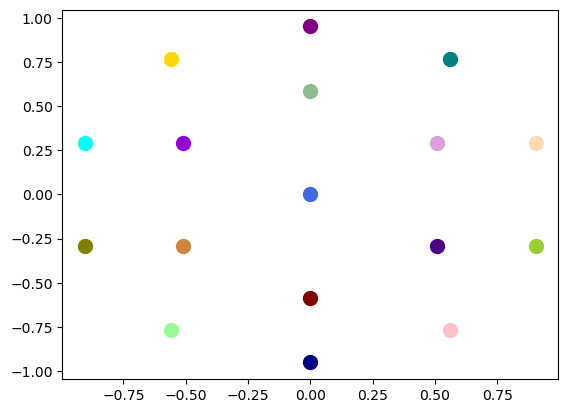

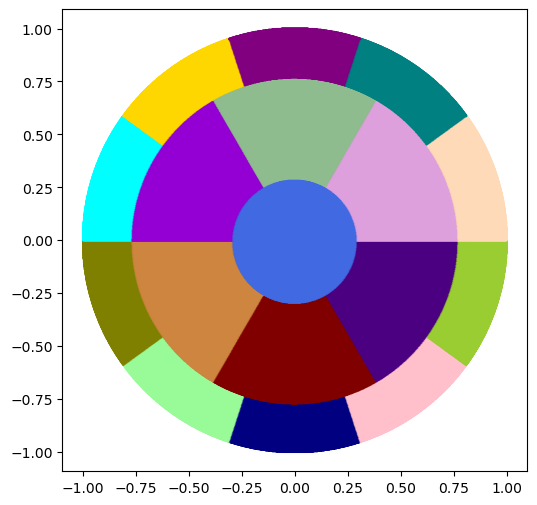

In [10]:
N = 3
n = 1024

Ngrids,Ngrid_in_ring, centres, amu, rs, alphas, xs, ys, zs, area, parea = generate_grid_coordinates_nb(N)

x = np.linspace(-1,1,n)

xg, yg = np.meshgrid(x, x)
rg = np.sqrt(xg**2 + yg**2)


xg = np.where(rg>1, np.nan, xg)
yg = np.where(rg>1, np.nan, yg)
rg = np.where(rg>1, np.nan, rg)
theta_g = np.arctan2(xg, yg) + np.pi / 2
theta_g = np.where(theta_g<0, theta_g + 2*np.pi, theta_g)

r = np.unique(np.round(rs, decimals=6))

#TODO change the lim to have the same area as in starsim???
lim_r = np.zeros(N)
for i in range(len(lim_r)-1):
    lim_r[i] = (r[i+1] + r[i]) / 2

lim_r[-1] = 1
print(lim_r)


typ_ring = np.zeros(n**2)
n_ring = np.zeros(n**2)
offset_ring = np.zeros(n**2)


typ_cell = np.zeros((n**2))

rg = rg.reshape(n**2)

for i in range(n**2):
    if rg[i]>=0:
        typ_ring[i] = np.argwhere(lim_r>=rg[i]).min()
        offset_ring[i] = np.sum(Ngrid_in_ring[:int(typ_ring[i])])
        n_ring[i] = Ngrid_in_ring[int(typ_ring[i])]



n_ring = n_ring.reshape(n, n)
offset_ring = offset_ring.reshape(n, n)
typ_cell = np.round((theta_g.reshape(n,n) + np.pi/2) % (2 * np.pi) / (2*np.pi /(n_ring))) % n_ring + offset_ring

colors = ['royalblue', 'maroon', 'indigo', 'plum', 'darkseagreen', 'darkviolet', 'peru', 'navy', 'pink', 'yellowgreen', 'peachpuff', 'teal', 'purple', 'gold', 'aqua', 'olive', 'palegreen', 'red']

for i in range(len(xs)):
    plt.scatter(ys[i], zs[i], color=colors[i], s=100)
plt.show()
xg = xg.reshape(n**2)
yg = yg.reshape(n**2)
typ_cell = np.flip(typ_cell, axis=1).reshape(n**2)


# Extend color map if needed
colors = ['royalblue', 'maroon', 'indigo', 'plum', 'darkseagreen', 'darkviolet',
          'peru', 'navy', 'pink', 'yellowgreen', 'peachpuff', 'teal', 'purple',
          'gold', 'aqua', 'olive', 'palegreen']

cmap = ListedColormap(colors)

# Plot
plt.figure(figsize=(6, 6))
plt.axis('equal')
plt.scatter(xg, yg, c=typ_cell, cmap=cmap, s=1)

# Plot centers
for i in range(len(xs)):
    plt.scatter(ys[i], zs[i], color=colors[i % len(colors)], s=100)

plt.show()

In [11]:
def projection_pxl_to_ss_grid_ground_truth(Ngrid_in_ring, rs, n_pxls):
    x = np.linspace(-1,1,n_pxls)

    xg, yg = np.meshgrid(x, x)
    rg = np.sqrt(xg**2 + yg**2)


    xg = np.where(rg>1, np.nan, xg)
    yg = np.where(rg>1, np.nan, yg)
    rg = np.where(rg>1, np.nan, rg)
    theta_g = np.arctan2(xg, yg) + np.pi / 2
    theta_g = np.where(theta_g<0, theta_g + 2*np.pi, theta_g)

    r = np.unique(np.round(rs, decimals=6))

    #TODO change the lim to have the same area as in starsim???
    lim_r = np.zeros(N)
    for i in range(len(lim_r)-1):
        lim_r[i] = (r[i+1] + r[i]) / 2

    lim_r[-1] = 1

    typ_ring = np.zeros(n_pxls**2)
    n_ring = np.zeros(n_pxls**2)
    offset_ring = np.zeros(n_pxls**2)


    typ_cell = np.zeros((n_pxls**2))

    rg = rg.reshape(n_pxls**2)

    for i in range(n_pxls**2):
        if rg[i]>=0:
            typ_ring[i] = np.argwhere(lim_r>=rg[i]).min()
            offset_ring[i] = np.sum(Ngrid_in_ring[:int(typ_ring[i])])
            n_ring[i] = Ngrid_in_ring[int(typ_ring[i])]



    n_ring = n_ring.reshape(n_pxls, n_pxls)
    offset_ring = offset_ring.reshape(n_pxls, n_pxls)
    typ_cell = np.round((theta_g.reshape(n_pxls,n_pxls) + np.pi/2) % (2 * np.pi) / (2*np.pi /(n_ring))) % n_ring + offset_ring
    typ_cell = np.flip(typ_cell, axis=1)
    return typ_cell, xg, yg

from numba import njit
import numpy as np

def projection_pxl_to_ss_grid(Ngrid_in_ring, rs, n_pxls):
    N = len(Ngrid_in_ring)
    x = np.linspace(-1.0, 1.0, n_pxls)
    xg = np.empty((n_pxls, n_pxls))
    yg = np.empty((n_pxls, n_pxls))
    rg = np.empty((n_pxls, n_pxls))
    theta_g = np.empty((n_pxls, n_pxls))
    
    for i in range(n_pxls):
        for j in range(n_pxls):
            x_val = x[j]
            y_val = x[i]
            r_val = np.sqrt(x_val**2 + y_val**2)
            if r_val > 1.0:
                xg[i, j] = np.nan
                yg[i, j] = np.nan
                rg[i, j] = np.nan
                theta_g[i, j] = np.nan
            else:
                xg[i, j] = x_val
                yg[i, j] = y_val
                rg[i, j] = r_val
                angle = np.arctan2(x_val, y_val) + np.pi / 2.0
                theta_g[i, j] = angle if angle >= 0 else angle + 2 * np.pi

    # Compute lim_r from rs
    r = np.empty_like(rs)
    for i in range(rs.shape[0]):
        r[i] = rs[i]
    r_sorted = np.sort(r)
    r_unique = np.empty_like(r)
    count = 0
    for i in range(r_sorted.shape[0]):
        val = np.round(r_sorted[i], 6)
        if count == 0 or val != r_unique[count - 1]:
            r_unique[count] = val
            count += 1
    r_unique = r_unique[:count]

    lim_r = np.empty(N)
    for i in range(N - 1):
        lim_r[i] = (r_unique[i + 1] + r_unique[i]) / 2.0
    lim_r[N - 1] = 1.0


    typ_cell = np.zeros((n_pxls, n_pxls))
    
    for i in range(n_pxls):
        for j in range(n_pxls):
            r_val = rg[i, j]
            if not np.isnan(r_val):
                # Find ring
                ring = 0
                while ring < N and lim_r[ring] < r_val:
                    ring += 1
                if ring >= N:
                    ring = N - 1
                offset = 0
                for k in range(ring):
                    offset += Ngrid_in_ring[k]
                n_cells = Ngrid_in_ring[ring]
                angle = theta_g[i, j]
                idx = int(np.round(((angle + np.pi / 2.0) % (2 * np.pi)) / (2 * np.pi / n_cells))) % n_cells
                typ_cell[i, j] = offset + idx
            else: 
                typ_cell[i, j] = np.nan

    # Flip horizontally
    typ_cell = typ_cell[:, ::-1]
    return typ_cell, xg, yg



In [63]:
N = 35
n_pxls = 1028

Ngrids,Ngrid_in_ring, centres, amu, rs, alphas, xs, ys, zs, area, parea = generate_grid_coordinates_nb(N)
typ_cell, xg, yg = projection_pxl_to_ss_grid(Ngrid_in_ring, rs, n_pxls)


In [64]:
tot_cell = np.sum(Ngrid_in_ring)
# print(tot_cell)
s = 0
for i in range(tot_cell):
    counts = np.sum(typ_cell==i)
    if counts == 0:
        s += 1
        # print(i)

print(s)

2


In [14]:
# # Extend color map if needed
# colors = ['royalblue', 'maroon', 'indigo', 'plum', 'darkseagreen', 'darkviolet',
#           'peru', 'navy', 'pink', 'yellowgreen', 'peachpuff', 'teal', 'purple',
#           'gold', 'aqua', 'olive', 'palegreen']

# if np.nanmax(typ_cell) >= len(colors):
#     from itertools import cycle, islice
#     colors = list(islice(cycle(colors), int(np.nanmax(typ_cell)) + 1))
# cmap = ListedColormap(colors)


# # Plot
# plt.figure(figsize=(6, 6))
# plt.axis('equal')
# plt.scatter(xg, yg, c=typ_cell, cmap=cmap, s=1, marker='.', alpha=0.7)

# # Plot centers
# for i in range(len(xs)):
#     plt.scatter(ys[i], zs[i], color=colors[i % len(colors)], s=100)
# plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/projection/projection_N_{}_n_{}.png'.format(N, n_pxls))
# plt.show()

In [15]:
def starsim_grid_to_pxl(vec_grid, values, grid_size=1028, sigma=2.5, cut_off=0.0):
    # Extract y and z coordinates
    yz_coords = vec_grid[:, 1:3]
    types = np.argmax(values, axis=1)

    y_coords = yz_coords[:, 0]
    z_coords = yz_coords[:, 1]

    y_norm = ((y_coords - y_coords.min()) / (y_coords.max() - y_coords.min()) * (grid_size - 1)).astype(int)
    z_norm = ((z_coords - z_coords.min()) / (z_coords.max() - z_coords.min()) * (grid_size - 1)).astype(int)



    # Create the grid
    meshgrid_values = np.zeros((grid_size, grid_size))
    for yi, zi, val in zip(y_norm, z_norm, types):
        meshgrid_values[zi, yi] = val  # Note: [z, y] indexing

    spot_map = np.zeros((grid_size, grid_size))
    faculae_map = np.zeros((grid_size, grid_size))

    spot_map[meshgrid_values==1] = 1
    spot_map = gaussian_filter(spot_map, sigma=sigma)
    spot_map[spot_map>=cut_off] = 1
    spot_map[spot_map<cut_off] = 0


    faculae_map[meshgrid_values==2] = 1
    faculae_map = gaussian_filter(faculae_map, sigma=sigma)
    faculae_map[faculae_map>=cut_off] = 1
    faculae_map[faculae_map<cut_off] = 0


    return spot_map, faculae_map

In [16]:
def simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path, dT_fc=None):
    """
    Iniialization of the starsim simulation for a particular set of parameters

    Params:
            -Q: facular_area_ratio
    Return:
            - ss: starsim object

    """
    
    #create the starsim object
    ss=starsim.StarSim(conf_file_path=conf_file_path)


    #set the Q parameter
    ss.active_region_types=type_list

    if dT_fc !=None:
        ss.facula_T_contrast = dT_fc

    #initialize the spot
    overlap=True

    #TODO: more modulable
    Nspots=len(spot_size_list)
    ss.spot_map=np.zeros([Nspots,8])
    for j in range(Nspots):
        ss.spot_map[j][0]=type_list[j]
        ss.spot_map[j][2]=200#lifetime spot
        ss.spot_map[j][1]=0#appearance time
        ss.spot_map[j][3]=latitude_list[j]#latitude (degrees) [0,180]
        ss.spot_map[j][4]=longitude_list[j]#longitude (degrees)	[0,360]
        ss.spot_map[j][5]=spot_size_list[j]#spot size (degrees)
    return ss

In [91]:
type_list = [0]
spot_size_list = [10]
latitude_list = [90]
longitude_list = [250]

period = 25
periods_nbr = 0.8
point_nbr = 1


t=np.linspace(0,period *periods_nbr,int(period *periods_nbr*point_nbr))




In [92]:
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun_sdo_ph.conf"

ss = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss.phoenix_spectra = 1
ss.compute_forward(observables=['lc', 'rv'],t=t)

3
PHOENIX spectra
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [20/20]%00%. [19/20]%%RV shift
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [20/20]%00%. [19/20]%%

In [93]:
for t_i in t:
    vec_grid = np.load('/home/sophie-stucki/starsim/starsim/gif/vec_gridt{:.4f}.npy'.format(t_i))
    values   = np.load('/home/sophie-stucki/starsim/starsim/gif/typt{:.4f}.npy'.format(t_i))


    spot_map, faculae_map = starsim_grid_to_pxl(vec_grid, values, 1028, sigma=3.5, cut_off=1e-7)

    np.savetxt('/home/sophie-stucki/starsim/starsim/SDO_input/spot_map_{}.txt'.format(t_i), spot_map)
    np.savetxt('/home/sophie-stucki/starsim/starsim/SDO_input/faculae_map_{}.txt'.format(t_i), faculae_map)


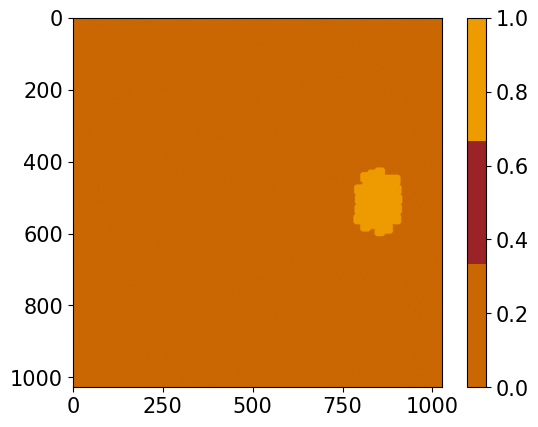

In [101]:
t_i = t[10]
vec_grid = np.load('/home/sophie-stucki/starsim/starsim/gif/vec_gridt{:.4f}.npy'.format(t_i))
values   = np.load('/home/sophie-stucki/starsim/starsim/gif/typt{:.4f}.npy'.format(t_i))


spot_map, faculae_map = starsim_grid_to_pxl(vec_grid, values, 1028,  sigma=3.5, cut_off=1e-7)

colors = ['#CA6702', '#9B2226', '#EE9B00']
cmap = ListedColormap(colors)

plt.imshow(spot_map, cmap=cmap)
plt.colorbar()

In [95]:
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun_sdo.conf"

ss_sdo = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_sdo.compute_forward(observables=['lc', 'rv'],t=t)

3
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [20/20]%00%. [19/20]%% 

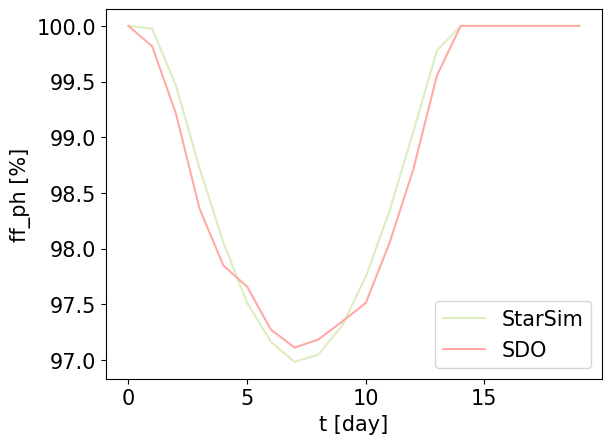

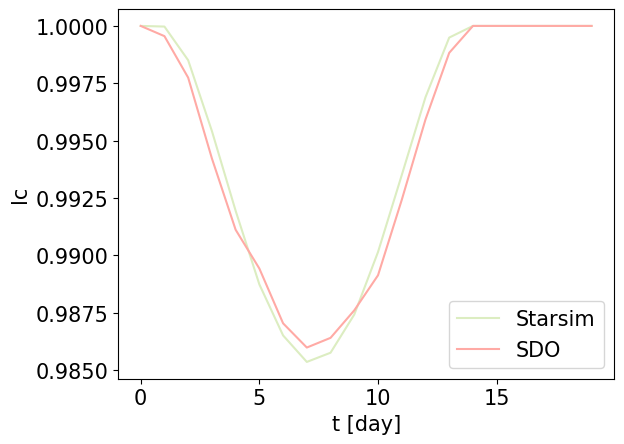

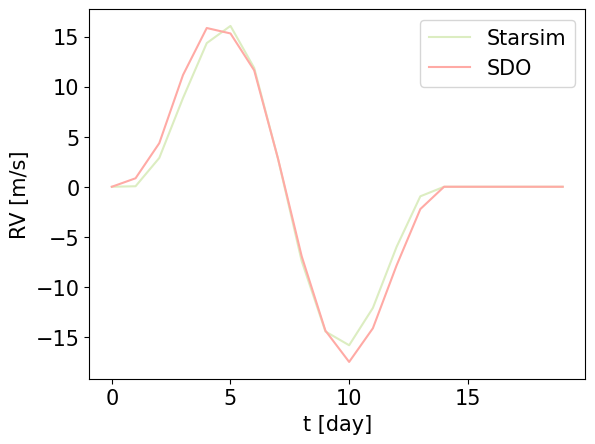

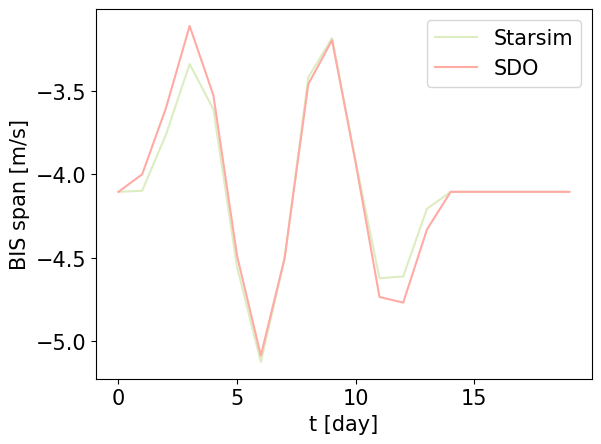

In [96]:
plt.rcParams['font.size'] = 15

plt.plot(ss.results['ff_ph'], label='StarSim', color='#dcedc1')
plt.plot(ss_sdo.results['ff_ph'], label='SDO', color='#ffaaa5')
plt.xlabel('t [day]')
plt.ylabel('ff_ph [%]')
plt.legend()
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/projection/ff_ph_types_{}.png'.format(type_list), dpi=300, bbox_inches='tight')
plt.show()

plt.plot(ss.results['lc'], label='Starsim', color='#dcedc1')
plt.plot(ss_sdo.results['lc'], label='SDO', color='#ffaaa5')
plt.xlabel('t [day]')
plt.ylabel('lc')
plt.legend()
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/projection/lc_types_{}.png'.format(type_list), dpi=300, bbox_inches='tight')
plt.show()

plt.plot(ss.results['rv'], label='Starsim', color='#dcedc1')
plt.plot(ss_sdo.results['rv'], label='SDO', color='#ffaaa5')
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.legend()
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/projection/rv_types_{}.png'.format(type_list), dpi=300, bbox_inches='tight')
plt.show()

plt.plot(ss.results['bis'], label='Starsim', color='#dcedc1')
plt.plot(ss_sdo.results['bis'], label='SDO', color='#ffaaa5')
plt.xlabel('t [day]')
plt.ylabel('BIS span [m/s]')
plt.legend()
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/projection/bis_types_{}.png'.format(type_list), dpi=300, bbox_inches='tight')
plt.show()

In [97]:
ss_sdo.results['ff_sp']

array([0.        , 0.18326583, 0.78760119, 1.64473754, 2.15196027,
       2.3421368 , 2.72742563, 2.88941684, 2.81741538, 2.6565543 ,
       2.48832495, 1.9503133 , 1.2914731 , 0.44442477, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [22]:
plt.rcParams['font.size'] = 18

def update(frame, ax, fig, lags, scalar_map, t, rv_sim, CCF_p, RV, BIS, raw_xbis, raw_ybis, lc, path_grid):
    ax[1,0].cla()
    ax[1,1].cla()
    lag = lags[frame]

    color_val = scalar_map.to_rgba(rv_sim[lag])
    
    #plot RVs
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,2].plot(t[i],rv_sim[i], color=color_val,marker='.', markersize=12)
    ax[0,2].set_xlim(t.min(),t.max())
    ax[0,2].set_ylim(rv_sim.min()-np.abs(rv_sim.min())/10,rv_sim.max()+np.abs(rv_sim.max())/10)
    ax[0,2].plot(t[:lag],rv_sim[:lag],color='gray', alpha=0.2, linewidth= 1)
    
    #plot CCF
    ax[1,0].plot(RV[:],CCF_p[lag], color=color_val,alpha=0.9)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,0].plot(RV[:],CCF_p[i], color=color_val,alpha=0.1)


    #plot BIS (mean diff)
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,2].plot(t[i],BIS[i], color=color_val,marker='.', linestyle='None', markersize=12)
    ax[1,2].plot(t[:lag],BIS[:lag],color='gray', alpha=0.2, linewidth= 1)

    #plot BIS
    ax[1,1].plot(raw_xbis[lag] - (np.max(raw_xbis[lag]) + np.min(raw_xbis[lag])) / 2,raw_ybis[lag], color=color_val,alpha=1)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,1].plot(raw_xbis[i] - (np.max(raw_xbis[i]) + np.min(raw_xbis[i])) / 2,raw_ybis[i], color=color_val,alpha=0.1)
    ax[1,1].set_xlim(-40, 40)


    #plot flux intensity
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,1].plot(t[i],lc[i], color=color_val,marker='.', markersize=12)
    ax[0,1].set_xlim(t.min(),t.max())
    ax[0,1].plot(t[:lag],lc[:lag],color='gray', alpha=0.2, linewidth= 1)
        
    #generate stellar grid
    x=np.linspace(-0.999,0.999,1000)
    h=np.sqrt((1-x**2)/(np.tan(0)**2+1))

    
    color_dict = { 0:'#CA6702', 1:'#9B2226', 2:'#EE9B00', 3:'#0A9396'}
    #0: photosphere, 1: spot, 2: faculae, 3: planet
    
    vec_grid=np.load(path_grid+'vec_gridt{:.4f}.npy'.format(t[lag]))
    typ=np.load(path_grid+'typt{:.4f}.npy'.format(t[lag]))
    
    #identifies which type of grid element is covering the pixel: photosphere, spot, facualae or planet
    ax[0,0].scatter(vec_grid[:,1],vec_grid[:,2], color=[ color_dict[np.argmax(i)] for i in typ ],s=50, alpha=0.8)
    #ax[0,0].plot(x,h,'k')
    
    ax[1,0].set_ylabel('CCF power')
    ax[1,0].set_xlabel('RV (m/s)')
    ax[1,0].set_ylim(CCF_p.min()-np.abs(CCF_p.min())/10,CCF_p.max()+np.abs(CCF_p.max())/10)
    ax[0,2].set_ylabel('RV (m/s)')
    ax[0,2].set_xlabel('t (d)')
    ax[0,1].set_ylabel('f')
    ax[0,1].set_xlabel('t (d)')
    ax[1,2].set_ylabel('BIS span')
    ax[1,2].set_xlabel('t (D)')
    ax[1,1].set_ylabel('')
    ax[1,1].set_xlabel('BIS')

    ax[0,0].locator_params(axis='y',nbins=5)
    ax[1,0].locator_params(axis='x',nbins=5)

    ax[0,1].ticklabel_format(axis='both', style='sci')
    ax[1,0].ticklabel_format(axis='both', style='sci')

    ax[0,0].tick_params(grid_alpha=0.7)
    ax[0,1].tick_params(grid_alpha=0.7)
    ax[0,2].tick_params(grid_alpha=0.7)
    ax[1,0].tick_params(grid_alpha=0.7)
    ax[1,1].tick_params(grid_alpha=0.7)
    ax[1,2].tick_params(grid_alpha=0.7)

    fig.tight_layout()


def retrieve_observable(ss, t, pathdata, path_grid, output):
    """
    Load and save the #TODO

    Params:
            -ss: starsim object
            -t: timeframe
    
    """

    rv_sim=ss.results['rv']
    CCF=ss.results['CCF'][1:]
    RV=ss.results['CCF'][0]
    lc = ss.results['lc']
    BIS = ss.results['bis']
    raw_xbis = ss.results['raw_xbis']
    raw_ybis = ss.results['raw_ybis']




    '''
    Generate an animated GIF
    '''

    CCF_p =CCF[:] -np.mean(CCF,axis=0)

    lags = np.arange(len(t))


    # Normalize the continuous variable to map it to the range [0, 1] for the colormap
    norm = Normalize(vmin=-np.max((np.abs(rv_sim))), vmax=np.max((np.abs(rv_sim))))
    List = ['#104f5c', '#2c6570', '#477b83', '#639295', '#84a8a5', '#c7b7a0', '#e49a77', '#e5845f', '#de714d', '#d3603e', '#c65031']

    colormap = get_continuous_cmap(List)
    scalar_map = ScalarMappable(norm=norm, cmap=colormap)

    fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(30/1.5 + 2, 20/1.5))

    # Create an animation
    ani = FuncAnimation(fig, partial(update, ax=ax, fig=fig, lags=lags, scalar_map=scalar_map, t=t, rv_sim=rv_sim, CCF_p=CCF_p, RV=RV, BIS=BIS, raw_xbis=raw_xbis, raw_ybis=raw_ybis, lc=lc, path_grid=path_grid), frames=len(lags), repeat=False)

    # Save the animation as a video
    writer = FFMpegWriter(fps=3                      , metadata=dict(artist='Me'), bitrate=2400)

    
    ani.save(pathdata+output+'.gif', writer=writer)

In [23]:
plt.rcParams['font.size'] = 18

def update_sdo(frame, ax, fig, lags, scalar_map, t, rv_sim, CCF_p, RV, BIS, raw_xbis, raw_ybis, lc, path_grid):
    ax[1,0].cla()
    ax[1,1].cla()
    lag = lags[frame]

    color_val = scalar_map.to_rgba(rv_sim[lag])
    
    #plot RVs
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,2].plot(t[i],rv_sim[i], color=color_val,marker='.', markersize=12)
    ax[0,2].set_xlim(t.min(),t.max())
    ax[0,2].set_ylim(rv_sim.min()-np.abs(rv_sim.min())/10,rv_sim.max()+np.abs(rv_sim.max())/10)
    ax[0,2].plot(t[:lag],rv_sim[:lag],color='gray', alpha=0.2, linewidth= 1)
    
    #plot CCF
    ax[1,0].plot(RV[:],CCF_p[lag], color=color_val,alpha=0.9)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,0].plot(RV[:],CCF_p[i], color=color_val,alpha=0.1)


    #plot BIS (mean diff)
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,2].plot(t[i],BIS[i], color=color_val,marker='.', linestyle='None', markersize=12)
    ax[1,2].plot(t[:lag],BIS[:lag],color='gray', alpha=0.2, linewidth= 1)

    #plot BIS
    ax[1,1].plot(raw_xbis[lag] - (np.max(raw_xbis[lag]) + np.min(raw_xbis[lag])) / 2,raw_ybis[lag], color=color_val,alpha=1)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,1].plot(raw_xbis[i] - (np.max(raw_xbis[i]) + np.min(raw_xbis[i])) / 2,raw_ybis[i], color=color_val,alpha=0.1)
    ax[1,1].set_xlim(-40, 40)


    #plot flux intensity
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,1].plot(t[i],lc[i], color=color_val,marker='.', markersize=12)
    ax[0,1].set_xlim(t.min(),t.max())
    ax[0,1].plot(t[:lag],lc[:lag],color='gray', alpha=0.2, linewidth= 1)
        
    #generate stellar grid
    x=np.linspace(-0.999,0.999,1000)
    h=np.sqrt((1-x**2)/(np.tan(0)**2+1))

    
    colors = ['#CA6702', '#9B2226', '#EE9B00']
    cmap = ListedColormap(colors)
    #0: photosphere, 1: spot, 2: faculae, 3: planet
    
    map_fc = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/faculae_map_{}.txt').format(t[i])
    map_sp = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/spot_map_{}.txt').format(t[i])

    map = np.zeros(np.shape(map_sp))
    map[map_sp.isnan()] = np.nan
    map[map_sp==1] = 1
    map[map_fc==1] = 2

    
    #identifies which type of grid element is covering the pixel: photosphere, spot, facualae or planet
    ax[0,0].imshow(map, cmap=cmap, alpha=0.8)
    #ax[0,0].plot(x,h,'k')
    
    ax[1,0].set_ylabel('CCF power')
    ax[1,0].set_xlabel('RV (m/s)')
    ax[1,0].set_ylim(CCF_p.min()-np.abs(CCF_p.min())/10,CCF_p.max()+np.abs(CCF_p.max())/10)
    ax[0,2].set_ylabel('RV (m/s)')
    ax[0,2].set_xlabel('t (d)')
    ax[0,1].set_ylabel('f')
    ax[0,1].set_xlabel('t (d)')
    ax[1,2].set_ylabel('BIS span')
    ax[1,2].set_xlabel('t (D)')
    ax[1,1].set_ylabel('')
    ax[1,1].set_xlabel('BIS')

    ax[0,0].locator_params(axis='y',nbins=5)
    ax[1,0].locator_params(axis='x',nbins=5)

    ax[0,1].ticklabel_format(axis='both', style='sci')
    ax[1,0].ticklabel_format(axis='both', style='sci')

    ax[0,0].tick_params(grid_alpha=0.7)
    ax[0,1].tick_params(grid_alpha=0.7)
    ax[0,2].tick_params(grid_alpha=0.7)
    ax[1,0].tick_params(grid_alpha=0.7)
    ax[1,1].tick_params(grid_alpha=0.7)
    ax[1,2].tick_params(grid_alpha=0.7)

    fig.tight_layout()


def retrieve_observable_sdo(ss, t, pathdata, path_grid, output):
    """
    Load and save the #TODO

    Params:
            -ss: starsim object
            -t: timeframe
    
    """

    rv_sim=ss.results['rv']
    CCF=ss.results['CCF'][1:]
    RV=ss.results['CCF'][0]
    lc = ss.results['lc']
    BIS = ss.results['bis']
    raw_xbis = ss.results['raw_xbis']
    raw_ybis = ss.results['raw_ybis']




    '''
    Generate an animated GIF
    '''

    CCF_p =CCF[:] -np.mean(CCF,axis=0)

    lags = np.arange(len(t))


    # Normalize the continuous variable to map it to the range [0, 1] for the colormap
    norm = Normalize(vmin=-np.max((np.abs(rv_sim))), vmax=np.max((np.abs(rv_sim))))
    List = ['#104f5c', '#2c6570', '#477b83', '#639295', '#84a8a5', '#c7b7a0', '#e49a77', '#e5845f', '#de714d', '#d3603e', '#c65031']

    colormap = get_continuous_cmap(List)
    scalar_map = ScalarMappable(norm=norm, cmap=colormap)

    fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(30/1.5 + 2, 20/1.5))

    # Create an animation
    ani = FuncAnimation(fig, partial(update, ax=ax, fig=fig, lags=lags, scalar_map=scalar_map, t=t, rv_sim=rv_sim, CCF_p=CCF_p, RV=RV, BIS=BIS, raw_xbis=raw_xbis, raw_ybis=raw_ybis, lc=lc, path_grid=path_grid), frames=len(lags), repeat=False)

    # Save the animation as a video
    writer = FFMpegWriter(fps=3                      , metadata=dict(artist='Me'), bitrate=2400)

    
    ani.save(pathdata+output+'.gif', writer=writer)